# Dampak Diskon terhadap Profit

## Metodologi

1. Memfilter data pada kategori Teknologi di bulan April.
2. Menghitung `profit` untuk setiap tingkat diskon.
3. Memvisualisasikan `profit` per tingkat diskon.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('superstore_2017.csv')

## Filter Data pada Kategori Teknologi di Bulan April

Analisis difokuskan pada kategori Teknologi sebagai kategori yang mengalami kerugian pada bulan April.

In [2]:
df_tech = df[(df['order_month'] == 'April') & (df['category'] == 'Technology')]

## Hitung Profit per Tingkat Diskon

Data dikelompokkan berdasarkan `discount`, kemudian `profit` dihitung untuk setiap tingkat diskon.

In [3]:
df_agg = df_tech.pivot_table(index='discount', values='profit', aggfunc='sum')

df_agg

,profit
discount,
0.0,373.2921
20.0,569.4924
40.0,-182.5784
70.0,-3399.9800


## Visualisasi Profit per Tingkat Diskon

Menampilkan `profit` per tingkat diskon pada kategori Teknologi untuk mengidentifikasi pada tingkat diskon berapa profit mulai menurun.

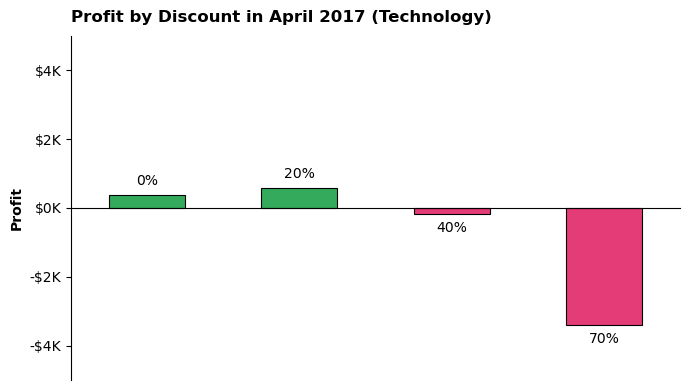

In [4]:
plt.figure(figsize=(7,4))
palette = ['#ff206e' if profit < 0 else '#20bf55' for profit in df_agg['profit']]
fig = sns.barplot(x=df_agg.index, y=df_agg['profit'], palette=palette, ls='-', lw=0.8, ec='black', alpha=1)

for bar in fig.patches:
    bar.set_width(0.5)
    bar.set_xy((bar.get_xy()[0] + 0.15, 0))

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':10,
              'alpha':1,
              'family':plt.rcParams['font.family']}

label_dict = {'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1,
              'family':plt.rcParams['font.family']}}

plt.title('Profit by Discount in April 2017 (Technology)', **title_dict)
plt.xlabel('')
plt.ylabel('Profit', **label_dict['y'])

ax = plt.gca()
ax.spines['bottom'].set_position(('data', 0))
ax.tick_params(which='major', axis='both', colors='black', direction='out', left=True, bottom=False)
ax.set_xticklabels('')
container = ax.containers[0]
labels = [f'{discount:.0f}%' for discount in df_agg.index]
ax.bar_label(container=container, labels=labels, size=10, weight='normal', color='black', padding=5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'-${abs(y/1_000):.0f}K' if y < 0 else f'${y/1_000:.0f}K'))
ax.set_ylim(-5000, 5000)

plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()